<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

## Prof. Dr. Eduardo Pécora
## Prof. Dr. Cassius Scarpin

# **Simulação: Análise dos dados de entrada**

Neste notebook cobriremos os seguintes tópicos:

1. Análise de outliers
2. Análise de autocorrelação
3. Teste de hipóteses


## Importar as bibliotecas necessárias

In [20]:
import numpy as np
import pandas as pd
import math

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

np.set_printoptions(legacy='1.25')

## Ler os dados

In [21]:
data_df = pd.read_csv("https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/SED/DadosSed/Dist03.csv")
data = data_df[data_df.columns[0]].to_numpy()

## Configuração da análise

Ajuste os parâmetros abaixo antes de executar o notebook.


In [22]:
# ┌─────────────────────────────────────────────────────────────────┐
# │  PARÂMETROS DE CONFIGURAÇÃO — edite aqui antes de executar      │
# └─────────────────────────────────────────────────────────────────┘

# Se True, remove os outliers consensuais (IQR ∩ Isolation Forest ∩ LOF)
# antes de prosseguir com autocorrelação e testes de distribuição.
deleta_outliers = False


## Analise descritiva

In [23]:
data_df.describe()

,normal
count,1000.000000
mean,0.023155
std,0.986490
min,-3.178055
25%,-0.690618
50%,0.031530
75%,0.733336
max,3.322772


## Algoritmos de detecção de outliers

In [24]:
def detect_outliers_iqr(data):
  Q1 = np.percentile(data, 25)
  Q3 = np.percentile(data, 75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = [x for x in data if x < lower_bound or x > upper_bound]
  return outliers

def detect_outliers_isolation_forest(data):
  model = IsolationForest(contamination='auto', random_state=42)
  model.fit(data.reshape(-1, 1))
  outlier_scores = model.decision_function(data.reshape(-1, 1))
  outliers = data[outlier_scores < 0]
  return outliers

def detect_outliers_local_outlier_factor(data):
  model = LocalOutlierFactor(n_neighbors=20, contamination='auto')
  outlier_scores = model.fit_predict(data.reshape(-1, 1))
  outliers = data[outlier_scores == -1]
  return outliers

# Detecção por cada método
iqr_outliers               = detect_outliers_iqr(data)
isolation_forest_outliers  = detect_outliers_isolation_forest(data)
lof_outliers               = detect_outliers_local_outlier_factor(data)

# Outliers consensuais (identificados pelos três métodos)
common_outliers = (
    set(iqr_outliers)
    .intersection(set(isolation_forest_outliers))
    .intersection(set(lof_outliers))
)

print("Outliers identificados pelos três métodos:", sorted(common_outliers))
print(f"Total de outliers consensuais: {len(common_outliers)}")
print(f"Tamanho original dos dados:    {len(data)}")

# ── Remoção de outliers (controlada por deleta_outliers) ─────────────────────
if deleta_outliers:
    if len(common_outliers) > 0:
        data = np.array([x for x in data if x not in common_outliers])
        print(f"\n[deleta_outliers = True]  {len(common_outliers)} outlier(s) removido(s).")
        print(f"Tamanho dos dados após remoção: {len(data)}")
    else:
        print("\n[deleta_outliers = True]  Nenhum outlier consensual encontrado — dados inalterados.")
else:
    print("\n[deleta_outliers = False] Outliers mantidos nos dados. Análise continua com n =", len(data))


Outliers identificados pelos três métodos: [-3.1780549012125188, 3.316189666828753, 3.322772392593383]
Total de outliers consensuais: 3
Tamanho original dos dados:    1000

[deleta_outliers = False] Outliers mantidos nos dados. Análise continua com n = 1000


## Análise de auto-correlação

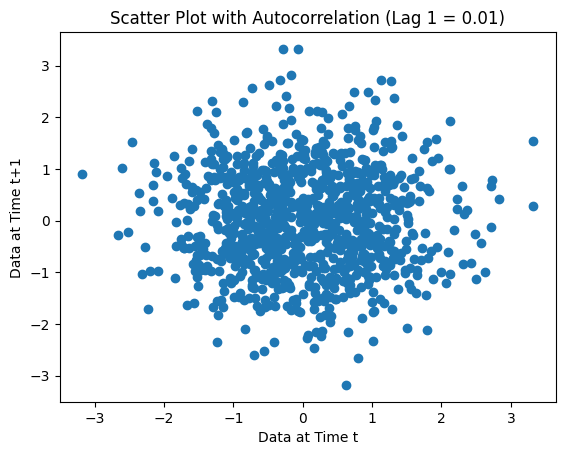

In [25]:
# Calculate autocorrelation with lag 1
autocorrelation_lag1 = pd.Series(data).autocorr(lag=1)

# Create a scatter plot of the data against the lagged data
plt.scatter(data[:-1], data[1:])
plt.xlabel("Data at Time t")
plt.ylabel("Data at Time t+1")
plt.title("Scatter Plot with Autocorrelation (Lag 1 = " + str(round(autocorrelation_lag1, 2)) + ")")
plt.show()


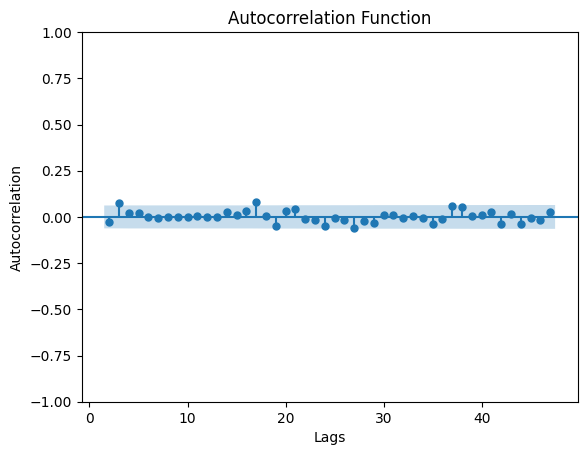

In [26]:
# Calculate autocorrelation function
# You can specify the number of lags to consider with the 'lags' parameter
acf_values = plot_acf(data, lags=range(2,48))

# Plot the autocorrelation function
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function")
plt.show()


## Testes de hipóteses

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6921: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


Results of Distribution Fit Tests:
- Normal:
  p-value: 0.4594
  Fits distribution: True
  Parameters: (0.023155397487630066, 0.9859968884102918)

- Uniform:
  p-value: 0.0000
  Fits distribution: False
  Parameters: (-3.1780549012125188, 6.5008272938059015)

- Exponential:
  p-value: 0.0000
  Fits distribution: False
  Parameters: (-3.1780549012125188, 3.2012102987001487)

- Gamma:
  p-value: 0.4754
  Fits distribution: True
  Parameters: (422.3501873843964, -20.241427852643213, 0.047980524415384765)

- Weibull:
  p-value: 0.6996
  Fits distribution: True
  Parameters: (3.332902729705271, -2.9605366001066313, 3.326020133393065)

- Beta:
  p-value: 0.5793
  Fits distribution: True
  Parameters: (26.813731041459576, 39.198206378625606, -6.652536897332968, 16.434681662103223)

- Lognormal:
  p-value: 0.4751
  Fits distribution: True
  Parameters: (0.03196005375241377, -30.821293529410987, 30.828704257674133)



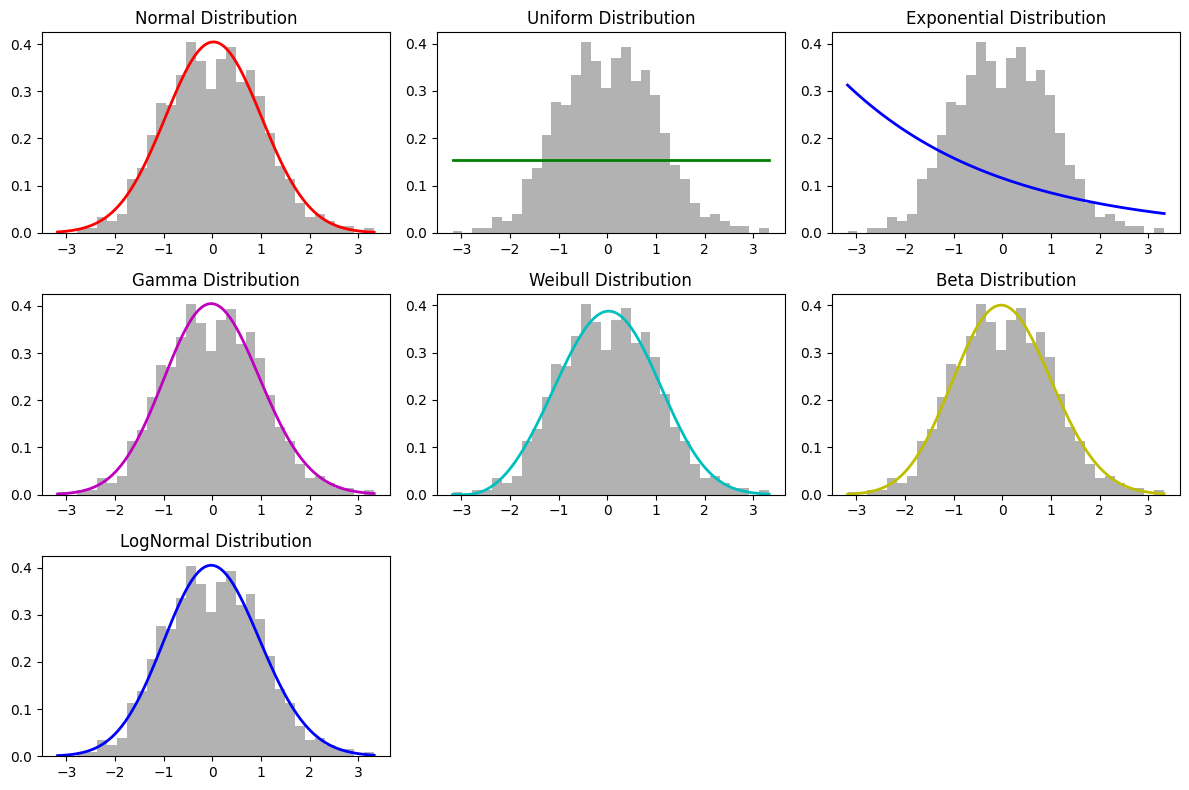

In [27]:
def test_distribution_fit(data):

  results = {}

  # Test for normality
  normal_params = stats.norm.fit(data)
  _, p_normal = stats.normaltest(data)
  results['normal'] = {'p-value': p_normal, 'fits': p_normal > 0.05, 'parameters': normal_params}

  # Test for uniformity
  uniform_params = stats.uniform.fit(data)
  _, p_uniform = stats.kstest(data, 'uniform', args=(np.min(data), np.max(data)))
  results['uniform'] = {'p-value': p_uniform, 'fits': p_uniform > 0.05, 'parameters': uniform_params}

  # Test for exponentiality
  exponential_params = stats.expon.fit(data)
  _, p_exponential = stats.kstest(data, 'expon')
  results['exponential'] = {'p-value': p_exponential, 'fits': p_exponential > 0.05, 'parameters': exponential_params}

  # Test for Gamma distribution
  gamma_params = stats.gamma.fit(data)
  _, p_gamma = stats.kstest(data, 'gamma', args=gamma_params)
  results['gamma'] = {'p-value': p_gamma, 'fits': p_gamma > 0.05, 'parameters': gamma_params}

  # Test for Weibull distribution
  weibull_params = stats.weibull_min.fit(data)
  _, p_weibull = stats.kstest(data, 'weibull_min', args=weibull_params)
  results['weibull'] = {'p-value': p_weibull, 'fits': p_weibull > 0.05, 'parameters': weibull_params}

  # Test for Beta distribution
  beta_params = stats.beta.fit(data)
  _, p_beta = stats.kstest(data, 'beta', args=beta_params)
  results['beta'] = {'p-value': p_beta, 'fits': p_beta > 0.05, 'parameters': beta_params}

  # Test for lognormal distribution
  logn_params = stats.lognorm.fit(data)  # Returns shape, loc, scale
  _, p_logn = stats.kstest(data, 'lognorm', args=logn_params)
  results['lognormal'] = {'p-value': p_logn, 'fits': p_logn > 0.05, 'parameters': logn_params}

  return results


results = test_distribution_fit(data)

print("Results of Distribution Fit Tests:")
for distribution, result in results.items():
  print(f"- {distribution.capitalize()}:")
  print(f"  p-value: {result['p-value']:.4f}")
  print(f"  Fits distribution: {result['fits']}")
  if 'parameters' in result:
    print(f"  Parameters: {result['parameters']}\n")


# Plot histograms and distribution lines for different distributions
plt.figure(figsize=(12, 8))

# Plot the distributions (you can adjust which ones to plot based on the results)

bins = math.ceil(math.sqrt(data.shape[0]))

plt.subplot(3, 3, 1)
plt.hist(data, bins=bins, density=True, alpha=0.6, color='gray')
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.norm.pdf(x, np.mean(data), np.std(data))
plt.plot(x, y, 'r-', lw=2)
plt.title("Normal Distribution")

plt.subplot(3, 3, 2)
plt.hist(data, bins=bins, density=True, alpha=0.6, color='gray')
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.uniform.pdf(x, loc=np.min(data), scale=np.max(data) - np.min(data))
plt.plot(x, y, 'g-', lw=2)
plt.title("Uniform Distribution")

plt.subplot(3, 3, 3)
plt.hist(data, bins=bins, density=True, alpha=0.6, color='gray')
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.expon.pdf(x, loc=np.min(data), scale=stats.expon.fit(data)[1])
plt.plot(x, y, 'b-', lw=2)
plt.title("Exponential Distribution")

plt.subplot(3, 3, 4)
plt.hist(data, bins=bins, density=True, alpha=0.6, color='gray')
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.gamma.pdf(x, *stats.gamma.fit(data))
plt.plot(x, y, 'm-', lw=2)
plt.title("Gamma Distribution")

plt.subplot(3, 3, 5)
plt.hist(data, bins=bins, density=True, alpha=0.6, color='gray')
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.weibull_min.pdf(x, *stats.weibull_min.fit(data))
plt.plot(x, y, 'c-', lw=2)
plt.title("Weibull Distribution")

plt.subplot(3, 3, 6)
plt.hist(data, bins=bins, density=True, alpha=0.6, color='gray')
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.beta.pdf(x, *stats.beta.fit(data))
plt.plot(x, y, 'y-', lw=2)
plt.title("Beta Distribution")

plt.subplot(3, 3, 7)
plt.hist(data, bins=bins, density=True, alpha=0.6, color='gray')
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.lognorm.pdf(x, *stats.lognorm.fit(data))
plt.plot(x, y, 'b-', lw=2)
plt.title("LogNormal Distribution")

plt.tight_layout()
plt.show()

## Seleção da melhor distribuição entre as que satisfazem H₀

Quando múltiplas distribuições não rejeitam H₀ (p-valor > 0,05), usamos **três critérios complementares** para escolher a mais adequada:

| Critério | O que mede | Preferência |
|---|---|---|
| **p-valor (KS)** | Compatibilidade com os dados | Maior é melhor |
| **AIC** (Akaike) | Qualidade do ajuste penalizada pela complexidade | Menor é melhor |
| **BIC** (Bayesian) | Idem, penalização maior para amostras grandes | Menor é melhor |

> **Regra prática:** entre as distribuições que não rejeitam H₀, escolha a que tiver **menor AIC** (ou BIC). Se houver empate próximo (ΔAIC < 2), prefira a de **menor número de parâmetros** (princípio da parcimônia).


In [28]:
def selecionar_melhor_distribuicao(data, alpha=0.05):
    """
    Entre as distribuições que não rejeitam H0 (KS test),
    rankeia pelo AIC e BIC e indica a melhor escolha.
    """

    distribuicoes = {
        'normal'     : stats.norm,
        'uniform'    : stats.uniform,
        'exponential': stats.expon,
        'gamma'      : stats.gamma,
        'weibull'    : stats.weibull_min,
        'lognormal'  : stats.lognorm,
        'beta'       : stats.beta,
    }

    n = len(data)
    registros = []

    for nome, dist in distribuicoes.items():
        try:
            params = dist.fit(data)
            k = len(params)                          # número de parâmetros estimados

            # Log-verossimilhança
            log_lik = np.sum(dist.logpdf(data, *params))

            # AIC e BIC
            aic = 2 * k - 2 * log_lik
            bic = k * np.log(n) - 2 * log_lik

            # Teste KS
            ks_stat, p_ks = stats.kstest(data, dist.cdf, args=params)

            registros.append({
                'Distribuição'  : nome.capitalize(),
                'p-valor (KS)' : round(p_ks, 4),
                'Satisfaz H₀'  : p_ks > alpha,
                'N° parâmetros': k,
                'Log-lik'      : round(log_lik, 2),
                'AIC'          : round(aic, 2),
                'BIC'          : round(bic, 2),
                '_params'      : params,
            })
        except Exception as e:
            registros.append({
                'Distribuição'  : nome.capitalize(),
                'p-valor (KS)' : None,
                'Satisfaz H₀'  : False,
                'N° parâmetros': None,
                'Log-lik'      : None,
                'AIC'          : None,
                'BIC'          : None,
                '_params'      : None,
            })

    df = pd.DataFrame(registros)

    # Separar as que satisfazem H0
    df_ok = df[df['Satisfaz H₀']].copy()

    # Ranquear pelo AIC (menor = melhor)
    if not df_ok.empty:
        df_ok = df_ok.sort_values('AIC')
        df_ok['Rank AIC'] = range(1, len(df_ok) + 1)

        aic_min = df_ok['AIC'].min()
        df_ok['ΔAIC'] = (df_ok['AIC'] - aic_min).round(2)
    else:
        df_ok['Rank AIC'] = []
        df_ok['ΔAIC'] = []

    return df, df_ok


# ── Executar ──────────────────────────────────────────────────────────────────
df_todos, df_ok = selecionar_melhor_distribuicao(data)

# Tabela completa
print("=" * 65)
print("RESULTADO COMPLETO — TODAS AS DISTRIBUIÇÕES TESTADAS")
print("=" * 65)
cols_show = ['Distribuição', 'p-valor (KS)', 'Satisfaz H₀', 'N° parâmetros', 'AIC', 'BIC']
print(df_todos[cols_show].to_string(index=False))

print()

# Tabela das que satisfazem H0
if df_ok.empty:
    print("Nenhuma distribuição satisfaz H₀ com α =", 0.05)
else:
    print("=" * 65)
    print("DISTRIBUIÇÕES QUE SATISFAZEM H₀  — ranqueadas por AIC")
    print("=" * 65)
    cols_ok = ['Rank AIC', 'Distribuição', 'p-valor (KS)', 'N° parâmetros', 'AIC', 'BIC', 'ΔAIC']
    print(df_ok[cols_ok].to_string(index=False))
    print()

    melhor = df_ok.iloc[0]
    print(f">>> MELHOR ESCOLHA: {melhor['Distribuição']} (AIC = {melhor['AIC']}, ΔAIC = 0)")

    if len(df_ok) > 1:
        segunda = df_ok.iloc[1]
        if segunda['ΔAIC'] < 2:
            print(f"    Atenção: {segunda['Distribuição']} também é competitiva (ΔAIC = {segunda['ΔAIC']} < 2).")
            print(f"    Nesse caso, prefira a de menor número de parâmetros: "
                  f"{min([melhor, segunda], key=lambda r: r['N° parâmetros'])['Distribuição']}.")


RESULTADO COMPLETO — TODAS AS DISTRIBUIÇÕES TESTADAS
Distribuição  p-valor (KS)  Satisfaz H₀  N° parâmetros     AIC     BIC
      Normal        0.4032         True              2 2813.67 2823.49
     Uniform        0.0000        False              2 3747.86 3757.67
 Exponential        0.0000        False              2 4331.06 4340.87
       Gamma        0.4754         True              3 2814.21 2828.94
     Weibull        0.6996         True              3     inf     inf
   Lognormal        0.4751         True              3 2814.23 2828.96
        Beta        0.5793         True              4 2815.82 2835.45

DISTRIBUIÇÕES QUE SATISFAZEM H₀  — ranqueadas por AIC
 Rank AIC Distribuição  p-valor (KS)  N° parâmetros     AIC     BIC  ΔAIC
        1       Normal        0.4032              2 2813.67 2823.49  0.00
        2        Gamma        0.4754              3 2814.21 2828.94  0.54
        3    Lognormal        0.4751              3 2814.23 2828.96  0.56
        4         Beta      

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  
  ## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

<a href="https://www.linkedin.com/in/cassius-scarpin-03062324/" target="_blank">Cassius Scarpin</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 20-03-2025       | 1.0     | Eduardo Pecora & Cassius Scarpin| Inicial               |
| 20-03-2025       | 1.1     | Eduardo Pecora | Decisão da Melhor Distribuição               |

<hr>

## <h3 align="center"> (c) Liga Data Science/ UFPR 2024. All rights reserved. <h3/>